In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 1. 加载数据

file_path = r"D:\数模协会\学术部\titanic\train.csv"
df = pd.read_csv(file_path)

In [3]:
# 2. 初步查看数据
print("数据形状：", df.shape)
print("\n字段列表：", df.columns.tolist())
print("\n数据前5行：")
print(df.head())
print("\n数据基本信息：")
df.info()
print("\n描述性统计：")
print(df.describe(include='all'))

数据形状： (891, 12)

字段列表： ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

数据前5行：
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STO

In [4]:
# 3. 检测重复行
print("重复行数量：", df.duplicated().sum())
# 若存在重复，删除
df = df.drop_duplicates()

重复行数量： 0


年龄异常值数量：0
票价异常值数量：116


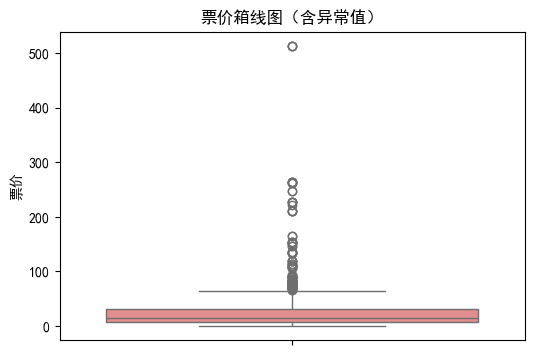

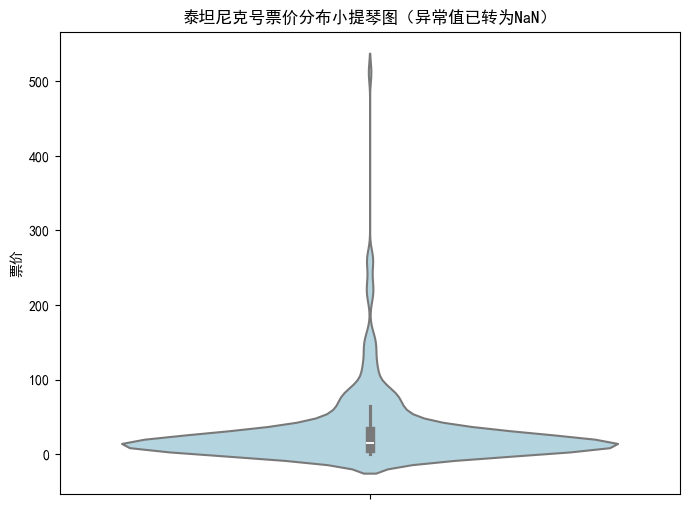

In [5]:
# 4. 检测并处理异常值
# 4.1 年龄异常值处理（年龄<0或>100视为异常，转为NaN）
age_outliers = (df['Age'] < 0) | (df['Age'] > 100)
print(f"年龄异常值数量：{age_outliers.sum()}")
df.loc[age_outliers, 'Age'] = np.nan

# 4.2 票价异常值检测
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
fare_outliers = (df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)
print(f"票价异常值数量：{fare_outliers.sum()}")

# 绘制箱线图
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Fare'], color='lightcoral')
plt.title('票价箱线图（含异常值）')
plt.ylabel('票价')
plt.show()

# 绘制小提琴图
plt.figure(figsize=(8, 6))
sns.violinplot(y=df['Fare'], inner='box', color='lightblue', linewidth=1.5)
plt.title('泰坦尼克号票价分布小提琴图（异常值已转为NaN）')
plt.ylabel('票价')
plt.show()

# 可以选择转为NaN
df.loc[fare_outliers, 'Fare'] = np.nan

In [6]:
# 5. 缺失值分析
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'缺失数量': missing, '缺失百分比': missing_percent})
print("\n缺失情况：")
print(missing_df[missing_df['缺失数量'] > 0])


缺失情况：
          缺失数量      缺失百分比
Age        177  19.865320
Fare       116  13.019080
Cabin      687  77.104377
Embarked     2   0.224467


In [7]:
# 5.1 删除 Embarked 缺失的行（只有2行）
embarked_missing = df['Embarked'].isnull()
print(f"Embarked 缺失行数：{embarked_missing.sum()}")
df = df.dropna(subset=['Embarked'])
print("已删除 Embarked 缺失的行。")

# 5.2 对 Age 进行填充（使用平均值）
age_mean = df['Age'].mean()
df['Age'] = df['Age'].fillna(age_mean)
print(f"Age 使用全局平均值 {age_mean:.2f} 填充。")

# 5.3 对 Fare 进行填充（使用中位数）
fare_median = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(fare_median)
print(f"Fare 使用全局中位数 {fare_median:.2f} 填充。")

# 5.4 Cabin 不处理，保持原样

# 查看处理后的缺失情况
print("\n处理缺失值后缺失情况：")
print(df.isnull().sum())

print("\n最终数据形状：", df.shape)

Embarked 缺失行数：2
已删除 Embarked 缺失的行。
Age 使用全局平均值 29.64 填充。
Fare 使用全局中位数 13.00 填充。

处理缺失值后缺失情况：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

最终数据形状： (889, 12)


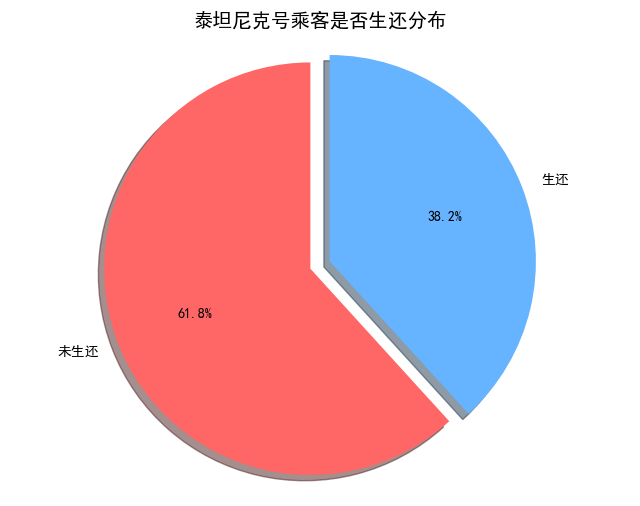

In [8]:
# 6. 单变量分析
# 6.1 生还率立体饼图
survived_counts = df['Survived'].value_counts().sort_index()  # 按索引排序确保顺序
sizes = survived_counts.values
labels = ['未生还', '生还']   # 对应索引 0 和 1

# 自定义颜色
colors = ['#ff6666', '#66b3ff']   # 红色为未生还，蓝色为生还

# 设置突出显示的扇区
explode = (0, 0.1)

# 绘制立体饼图
plt.figure(figsize=(8, 6))
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',   # 显示百分比
        shadow=True,          # 添加阴影产生立体感
        startangle=90)        # 起始角度

plt.axis('equal')             # 保证饼图为正圆
plt.title('泰坦尼克号乘客是否生还分布', fontsize=14)
plt.show()

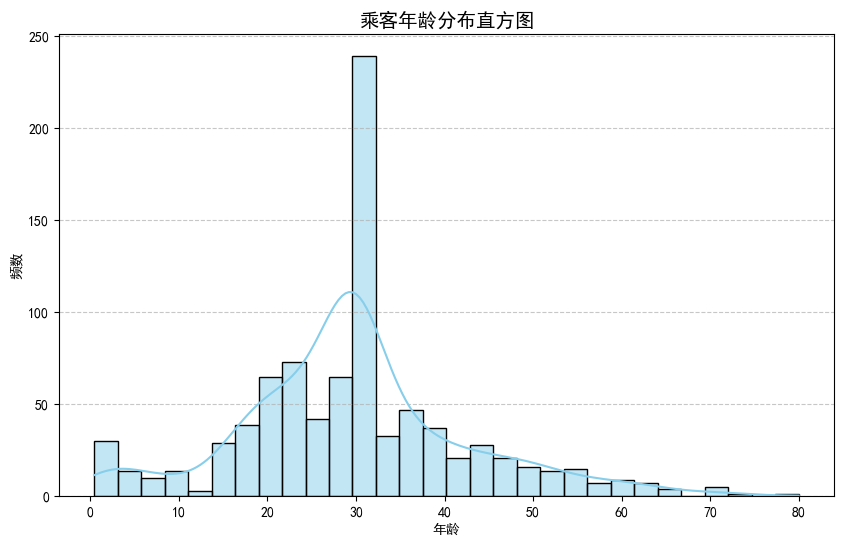

In [9]:
# 6.2 年龄分布直方图
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('乘客年龄分布直方图', fontsize=14)
plt.xlabel('年龄')
plt.ylabel('频数')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

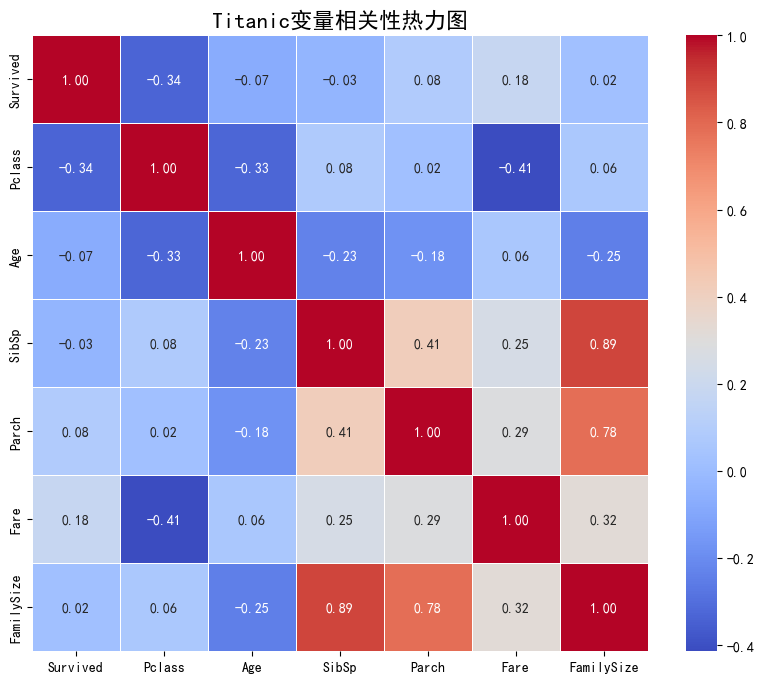

In [10]:
# 7. 双变量分析
# 7.1 绘制相关性热力图
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 选择需要绘制热力图的变量
heatmap_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']
corr_matrix = df[heatmap_cols].corr()

# 绘制相关性热力图
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,          # 显示相关系数
            cmap='coolwarm',     # 颜色风格
            fmt=".2f",           # 保留两位小数
            linewidths=0.5,
            square=True)

plt.title('Titanic变量相关性热力图', fontsize=16)
plt.show()

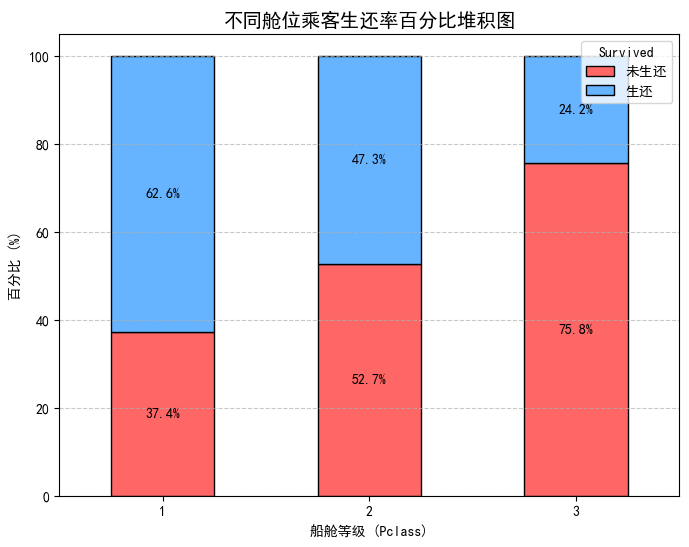

In [11]:
# 7.2 不同舱位乘客生还率百分比堆积图
pclass_survived = pd.crosstab(df['Pclass'], df['Survived'])

# 转换为百分比
df_percent = pclass_survived.div(pclass_survived.sum(axis=1), axis=0) * 100

# 绘制百分比堆积柱状图
ax = df_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#ff6666', '#66b3ff'],  # 未生还 / 生还
    edgecolor='black'
)

plt.title('不同舱位乘客生还率百分比堆积图', fontsize=14)
plt.xlabel('船舱等级 (Pclass)')
plt.ylabel('百分比 (%)')
plt.legend(['未生还', '生还'], title='Survived')

# 在柱子中间标注百分比
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

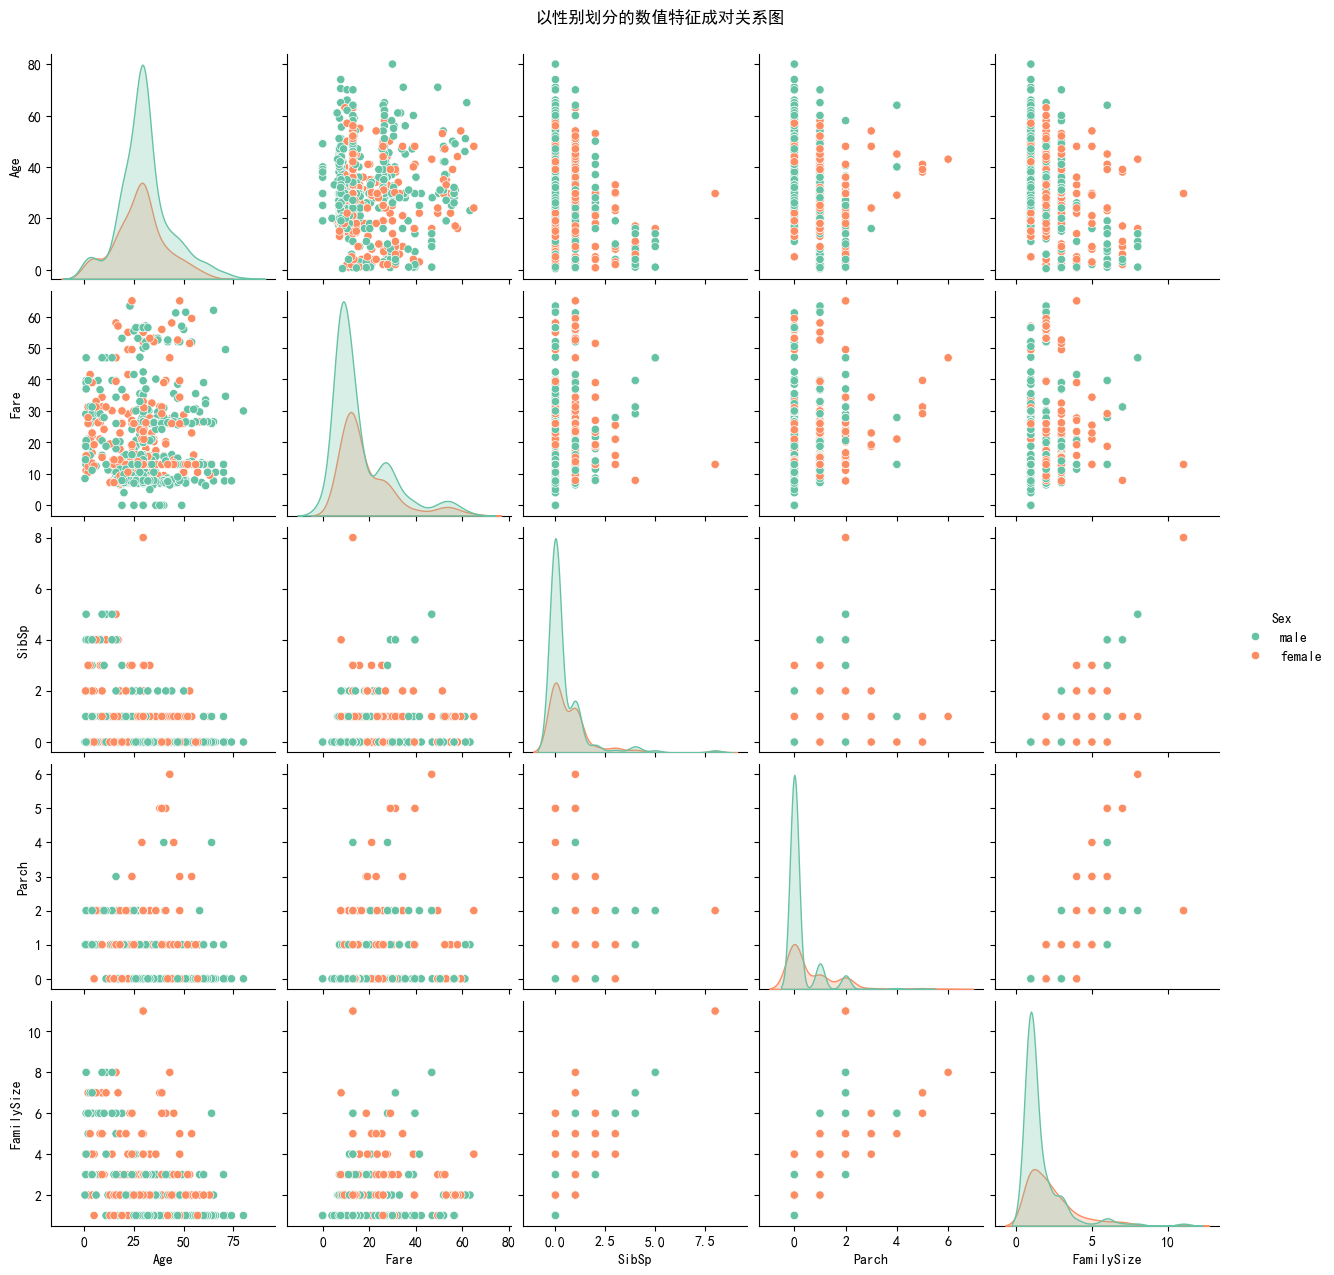

In [12]:
# 7.3 以性别为划分的数值特征 pairplot 图
# 选择要绘制的数值特征
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

# 绘制 pairplot，按性别着色
sns.pairplot(df, 
             hue='Sex',                # 按性别区分颜色
             vars=numeric_features,    # 只绘制指定的特征
             palette='Set2',            # 颜色调色板
             corner=False)              # 是否只显示下三角（False显示全矩阵）
plt.suptitle('以性别划分的数值特征成对关系图', y=1.02)
plt.show()

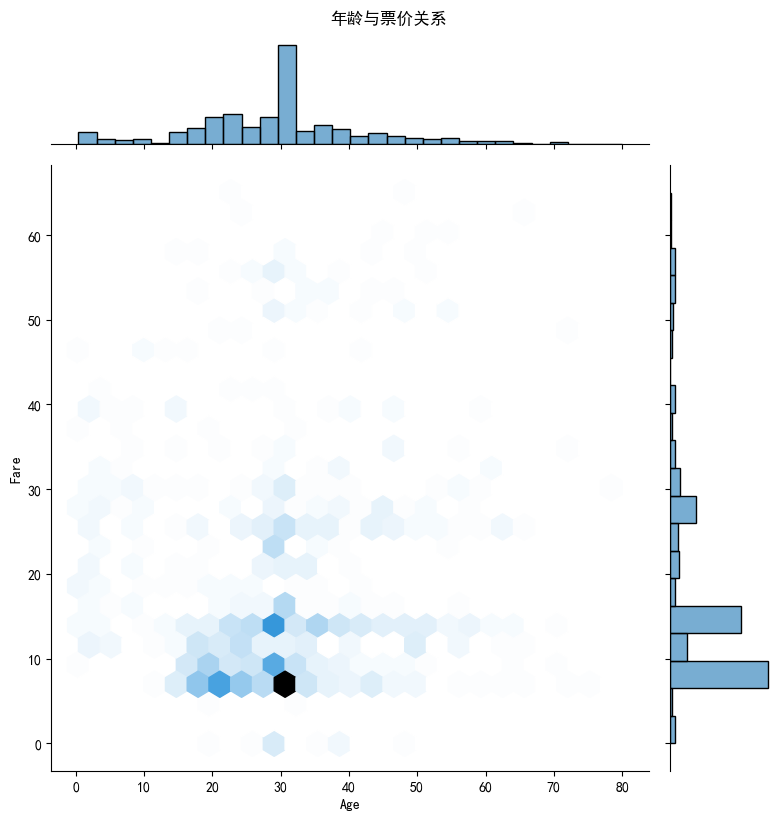

In [13]:
# 7.4 年龄与票价的关系
g1 = sns.jointplot(data=df, x='Age', y='Fare', kind='hex',
                   height=8, marginal_kws=dict(alpha=0.6))
g1.fig.suptitle('年龄与票价关系', y=1.02)
plt.show()